You are supposed to train and apply a boosting model for landcover classification. Below, you can find some code that already parses the data. For your submission, run and submit the extended jupyter notebook.

In [1]:
import numpy as np

In [2]:
# load data
train = np.load('./train.npz')
X_train = train["X"]
y_train = train["y"].reshape((-1,1))

test = np.load('./test.npz')
X_test = test["X"]
y_test = test["y"].reshape((-1,1))

classes = {
    1: "cultivated_land",
    2: "forest",
    3: "grassland",
    4: "shrubland",
    5: "water",
    8: "artificial_surface",
    9: "bareland"
}

In [3]:
print("Shape of training data: {}".format(X_train.shape))
print("Shape of training labels: {}".format(y_train.shape))
print("Shape of test data: {}".format(X_test.shape))
print("Shape of test labels: {}".format(y_test.shape))

Shape of training data: (6953, 12, 13, 13, 6)
Shape of training labels: (6953, 1)
Shape of test data: (1739, 12, 13, 13, 6)
Shape of test labels: (1739, 1)


The training and test set contain a few thousand instances. Each instance is based on image of size 13x13 pixels, which are available for 12 timestamps and 6 bands. That is, one is given an array of shape (12,13,13,6) for each instance. The label arrays contain the labels associated with the instances, where the central pixel/position determines the class of the (whole) image array for each instance, see below.

In [ ]:
# visualize some of the (image) data

import matplotlib.cm as cm
import matplotlib.pyplot as plt

idx = 0

print("Label (i.e., class of pixel in the center of the images) for image sequence: {}".format(classes[y_train[idx,0]]))

for year in range(12):
    fig, axs = plt.subplots(1, 6, figsize=(24, 4))
    for b in range(6):
        axs[b].imshow(X_train[idx, year, :, :, b], cmap=plt.get_cmap("Greys"))
        axs[b].set_title("Band {}".format(b+1))

### Question 1

In [5]:
# Extract central pixel features: shape (n_samples, 12, 6) -> reshape to (n_samples, 72)
def extract_central_pixels(X):
    # X: (n_samples, 12, 13, 13, 6)
    return X[:, :, 6, 6, :].reshape(X.shape[0], -1)

X_train_central = extract_central_pixels(X_train)
X_test_central = extract_central_pixels(X_test)

print("Reduced training feature shape:", X_train_central.shape)
print("Reduced test feature shape:", X_test_central.shape)

Reduced training feature shape: (6953, 72)
Reduced test feature shape: (1739, 72)


### Question 2

In [6]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [7]:
# Prepare labels as 1D array for scikit-learn
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

In [8]:
# Define parameter grid
param_grid = {
    'estimator': [DecisionTreeClassifier(max_depth=d, criterion='gini') for d in [1, 2, 3]],
    'n_estimators': [50, 100, 200]
}

In [9]:
# Custom estimator wrapper for grid search
class AdaBoostWithDepth(AdaBoostClassifier):
    def set_params(self, **params):
        if 'estimator' in params:
            self.estimator = params['estimator']
            del params['estimator']
        return super().set_params(**params)

In [10]:
# 2-fold cross-validation
cv = KFold(n_splits=2, shuffle=True, random_state=42)

In [11]:
# Grid search
grid = GridSearchCV(
    AdaBoostWithDepth(),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    refit=True
)
grid.fit(X_train_central, y_train_flat)

print("Best parameters:", grid.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid.best_score_))

Best parameters: {'estimator': DecisionTreeClassifier(max_depth=3), 'n_estimators': 200}
Best cross-validation accuracy: 0.7367


In [15]:
# Refit best model on all training data
best_model = grid.best_estimator_
best_model.fit(X_train_central, y_train_flat)

AdaBoostWithDepth(estimator=DecisionTreeClassifier(max_depth=3),
                  n_estimators=200)

In [16]:
# Evaluate on test set
y_pred = best_model.predict(X_test_central)
test_acc = accuracy_score(y_test_flat, y_pred)
print("Test accuracy: {:.4f}".format(test_acc))

Test accuracy: 0.7188


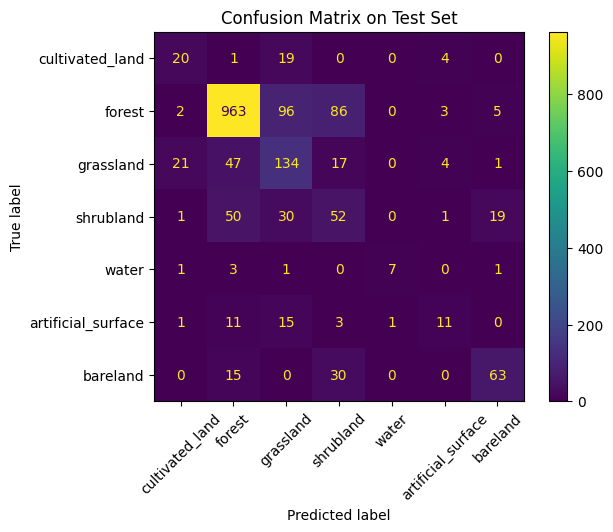

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test_flat, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[classes[c] for c in sorted(classes.keys())])
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.savefig("confusion_matrix.png", bbox_inches='tight')
plt.show()